# Task 04: Data Science Tool Mastery Project

## Project Overview

This project demonstrates practical proficiency in industry-standard
data science tools and Python libraries through an end-to-end analysis
of the Titanic dataset.

The project covers data loading, data exploration, data quality
assessment, data cleaning, numerical analysis, data visualization,
feature engineering, machine learning, model evaluation, and prediction
on unseen test data.

## Objectives

1. Master industry-standard data science tools and libraries.
2. Demonstrate practical data analysis skills.
3. Perform exploratory data analysis.
4. Create meaningful statistical visualizations.
5. Build and evaluate a machine learning model.
6. Generate predictions on unseen test data.
7. Create a portfolio-ready data science project.

## Tools and Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Dataset

The project uses the Titanic dataset.

- Training Dataset: 891 records and 12 columns
- Test Dataset: 418 records and 11 columns
- Target Variable: `Survived`

In [7]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# NumPy is used for numerical computations
import numpy as np

# Pandas is used for data manipulation and analysis
import pandas as pd

# Matplotlib is used for creating visualizations
import matplotlib.pyplot as plt

# Seaborn is used for statistical data visualization
import seaborn as sns

# Scikit-learn libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# OS module is used for file and directory operations
import os

# Suppress unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Set Seaborn theme for consistent visualizations
sns.set_theme(style="whitegrid")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [8]:
# ============================================================
# PROJECT PATH CONFIGURATION
# ============================================================

# Main project directory
PROJECT_PATH = r"C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery"

# Dataset directory
DATASET_PATH = os.path.join(
    PROJECT_PATH,
    "dataset"
)

# Main output directory
OUTPUT_PATH = os.path.join(
    PROJECT_PATH,
    "output"
)

# Directory for charts and visualizations
FIGURES_PATH = os.path.join(
    OUTPUT_PATH,
    "figures"
)

# Directory for analysis results
RESULTS_PATH = os.path.join(
    OUTPUT_PATH,
    "results"
)

# Directory for processed datasets
PROCESSED_DATA_PATH = os.path.join(
    OUTPUT_PATH,
    "processed_data"
)

# Display configured paths
print("Project Path :", PROJECT_PATH)
print("Dataset Path :", DATASET_PATH)
print("Output Path  :", OUTPUT_PATH)

Project Path : C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery
Dataset Path : C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\dataset
Output Path  : C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output


In [9]:
# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

# Create the required output directories
# exist_ok=True prevents errors if folders already exist
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


In [10]:
# ============================================================
# LOAD TRAINING AND TEST DATASETS
# ============================================================

# Define training dataset file path
TRAIN_FILE = os.path.join(
    DATASET_PATH,
    "titanic.csv"
)

# Define test dataset file path
TEST_FILE = os.path.join(
    DATASET_PATH,
    "test.csv"
)

# Load training dataset using Pandas
train_df = pd.read_csv(TRAIN_FILE)

# Load test dataset using Pandas
test_df = pd.read_csv(TEST_FILE)

# Display dataset dimensions
print("Training Dataset Shape:", train_df.shape)
print("Test Dataset Shape    :", test_df.shape)

Training Dataset Shape: (891, 12)
Test Dataset Shape    : (418, 11)


In [11]:
# ============================================================
# DISPLAY DATASET PREVIEW
# ============================================================

print("========== TRAINING DATA ==========")

# Display first five training records
display(train_df.head())

print("\n========== TEST DATA ==========")

# Display first five test records
display(test_df.head())

========== TRAINING DATA ==========


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



========== TEST DATA ==========


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("========== TRAINING DATA INFORMATION ==========\n")

# Display column names, data types and non-null values
train_df.info()

print("\n========== TEST DATA INFORMATION ==========\n")

# Display information for test dataset
test_df.info()

========== TRAINING DATA INFORMATION ==========

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

========== TEST DATA INFORMATION ==========

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ----------

In [13]:
# ============================================================
# CHECK DATASET COLUMNS
# ============================================================

print("Training Dataset Columns:")
print(train_df.columns.tolist())

print("\nTest Dataset Columns:")
print(test_df.columns.tolist())

# Identify columns that are present in training
# but absent in test dataset
training_only_columns = list(
    set(train_df.columns) - set(test_df.columns)
)

print("\nTraining-only Columns:")
print(training_only_columns)

Training Dataset Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Test Dataset Columns:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Training-only Columns:
['Survived']


In [14]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

# Generate descriptive statistics for numerical columns
statistical_summary = train_df.describe()

# Display statistical summary
display(statistical_summary)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Save statistical summary as CSV
statistical_summary.to_csv(
    os.path.join(
        RESULTS_PATH,
        "statistical_summary.csv"
    )
)

print("Statistical summary saved successfully.")

Statistical summary saved successfully.


In [16]:
# ============================================================
# DATA QUALITY ANALYSIS - MISSING VALUES
# ============================================================

# Calculate the number of missing values in each column
missing_values = train_df.isnull().sum()

# Calculate missing-value percentage
missing_percentage = (
    train_df.isnull().mean() * 100
).round(2)

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

# Sort columns by number of missing values
missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

# Display missing-value summary
display(missing_summary)

,Missing_Count,Missing_Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [17]:
# ============================================================
# SAVE MISSING VALUE REPORT
# ============================================================

# Define output path
missing_report_path = os.path.join(
    RESULTS_PATH,
    "missing_values.csv"
)

# Save missing-value analysis
missing_summary.to_csv(
    missing_report_path
)

print("Missing-value report saved successfully.")
print("Saved at:", missing_report_path)

Missing-value report saved successfully.
Saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\results\missing_values.csv


In [18]:
# ============================================================
# DUPLICATE RECORD ANALYSIS
# ============================================================

# Count duplicate rows in the training dataset
duplicate_count = train_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Calculate duplicate percentage
duplicate_percentage = (
    duplicate_count / len(train_df)
) * 100

print(
    f"Duplicate percentage: {duplicate_percentage:.2f}%"
)

Number of duplicate rows: 0
Duplicate percentage: 0.00%


In [19]:
# ============================================================
# TARGET VARIABLE ANALYSIS
# ============================================================

# Count survived and non-survived passengers
survival_counts = train_df["Survived"].value_counts()

print("Survival Counts:")
print(survival_counts)

print("\nSurvival Labels:")
print("0 = Did not survive")
print("1 = Survived")

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Labels:
0 = Did not survive
1 = Survived


In [20]:
# ============================================================
# SURVIVAL PERCENTAGE
# ============================================================

# Calculate survival percentage
survival_percentage = (
    train_df["Survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Survival Percentage:")
print(survival_percentage)

Survival Percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [21]:
# ============================================================
# NUMPY - AGE STATISTICAL ANALYSIS
# ============================================================

# Convert Age column into a NumPy array
# dropna() removes missing age values
age_array = train_df["Age"].dropna().to_numpy()

# Calculate statistics using NumPy
mean_age = np.mean(age_array)
median_age = np.median(age_array)
std_age = np.std(age_array)
minimum_age = np.min(age_array)
maximum_age = np.max(age_array)

# Display results
print("Age Statistics")
print("----------------------------")
print(f"Mean Age       : {mean_age:.2f}")
print(f"Median Age     : {median_age:.2f}")
print(f"Standard Deviation: {std_age:.2f}")
print(f"Minimum Age    : {minimum_age:.2f}")
print(f"Maximum Age    : {maximum_age:.2f}")

Age Statistics
----------------------------
Mean Age       : 29.70
Median Age     : 28.00
Standard Deviation: 14.52
Minimum Age    : 0.42
Maximum Age    : 80.00


In [22]:
# ============================================================
# NUMPY - FARE STATISTICAL ANALYSIS
# ============================================================

# Convert Fare column into a NumPy array
fare_array = train_df["Fare"].dropna().to_numpy()

# Calculate fare statistics
mean_fare = np.mean(fare_array)
median_fare = np.median(fare_array)
std_fare = np.std(fare_array)
minimum_fare = np.min(fare_array)
maximum_fare = np.max(fare_array)

# Display results
print("Fare Statistics")
print("----------------------------")
print(f"Mean Fare          : {mean_fare:.2f}")
print(f"Median Fare        : {median_fare:.2f}")
print(f"Standard Deviation : {std_fare:.2f}")
print(f"Minimum Fare       : {minimum_fare:.2f}")
print(f"Maximum Fare       : {maximum_fare:.2f}")

Fare Statistics
----------------------------
Mean Fare          : 32.20
Median Fare        : 14.45
Standard Deviation : 49.67
Minimum Fare       : 0.00
Maximum Fare       : 512.33


In [23]:
# ============================================================
# PANDAS - VALUE COUNTS
# ============================================================

# Count passengers according to gender
gender_counts = train_df["Sex"].value_counts()

print("Passenger Count by Gender:")
print(gender_counts)

Passenger Count by Gender:
Sex
male      577
female    314
Name: count, dtype: int64


In [24]:
# ============================================================
# PANDAS - VALUE COUNTS
# ============================================================

# Count passengers according to gender
gender_counts = train_df["Sex"].value_counts()

print("Passenger Count by Gender:")
print(gender_counts)

Passenger Count by Gender:
Sex
male      577
female    314
Name: count, dtype: int64


In [25]:
# ============================================================
# PANDAS - GROUPBY ANALYSIS
# ============================================================

# Calculate average survival rate by gender
survival_by_gender = (
    train_df
    .groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival Rate by Gender:")
print(survival_by_gender)

Survival Rate by Gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [26]:
# ============================================================
# SURVIVAL RATE BY PASSENGER CLASS
# ============================================================

# Calculate survival percentage for each passenger class
survival_by_class = (
    train_df
    .groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival Rate by Passenger Class:")
print(survival_by_class)

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [27]:
# ============================================================
# AGE GROUP ANALYSIS
# ============================================================

# Create age groups using Pandas cut()
train_df["Age_Group"] = pd.cut(
    train_df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        "Child",
        "Teenager",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

# Calculate survival rate by age group
age_group_survival = (
    train_df
    .groupby("Age_Group", observed=False)["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival Rate by Age Group:")
print(age_group_survival)

Survival Rate by Age Group:
Age_Group
Child          57.97
Teenager       42.86
Young Adult    38.27
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64


In [28]:
# ============================================================
# DATA CLEANING
# ============================================================

# Create a copy of the training dataset
clean_train_df = train_df.copy()

# Create a copy of the test dataset
clean_test_df = test_df.copy()

print("Training dataset copy created.")
print("Test dataset copy created.")

Training dataset copy created.
Test dataset copy created.


In [29]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Fill missing Age values with the median age
# Median is preferred because it is less affected by outliers
age_median = clean_train_df["Age"].median()

clean_train_df["Age"] = clean_train_df["Age"].fillna(
    age_median
)

clean_test_df["Age"] = clean_test_df["Age"].fillna(
    age_median
)


# Fill missing Fare values in test data
# using the training dataset median
fare_median = clean_train_df["Fare"].median()

clean_train_df["Fare"] = clean_train_df["Fare"].fillna(
    fare_median
)

clean_test_df["Fare"] = clean_test_df["Fare"].fillna(
    fare_median
)


# Fill missing Embarked values with the mode
embarked_mode = clean_train_df["Embarked"].mode()[0]

clean_train_df["Embarked"] = clean_train_df["Embarked"].fillna(
    embarked_mode
)

clean_test_df["Embarked"] = clean_test_df["Embarked"].fillna(
    embarked_mode
)

print("Missing values handled successfully.")

Missing values handled successfully.


In [30]:
# ============================================================
# VERIFY DATA CLEANING
# ============================================================

print("Missing values in cleaned training data:")
print(clean_train_df.isnull().sum())

print("\nMissing values in cleaned test data:")
print(clean_test_df.isnull().sum())

Missing values in cleaned training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Group      177
dtype: int64

Missing values in cleaned test data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [31]:
# ============================================================
# SAVE CLEANED TRAINING DATASET
# ============================================================

# Define path for cleaned training dataset
clean_train_path = os.path.join(
    PROCESSED_DATA_PATH,
    "titanic_cleaned.csv"
)

# Save cleaned training dataset
clean_train_df.to_csv(
    clean_train_path,
    index=False
)

print("Cleaned training dataset saved successfully.")
print("Saved at:", clean_train_path)

Cleaned training dataset saved successfully.
Saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\processed_data\titanic_cleaned.csv


In [32]:
# ============================================================
# SAVE CLEANED TEST DATASET
# ============================================================

# Define path for cleaned test dataset
clean_test_path = os.path.join(
    PROCESSED_DATA_PATH,
    "test_cleaned.csv"
)

# Save cleaned test dataset
clean_test_df.to_csv(
    clean_test_path,
    index=False
)

print("Cleaned test dataset saved successfully.")
print("Saved at:", clean_test_path)

Cleaned test dataset saved successfully.
Saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\processed_data\test_cleaned.csv


In [33]:
# ============================================================
# DISPLAY CLEANED DATA
# ============================================================

# Display first five records of cleaned training data
display(clean_train_df.head())

# Display dataset shape
print("Cleaned Training Dataset Shape:", clean_train_df.shape)
print("Cleaned Test Dataset Shape    :", clean_test_df.shape)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young Adult


Cleaned Training Dataset Shape: (891, 13)
Cleaned Test Dataset Shape    : (418, 11)


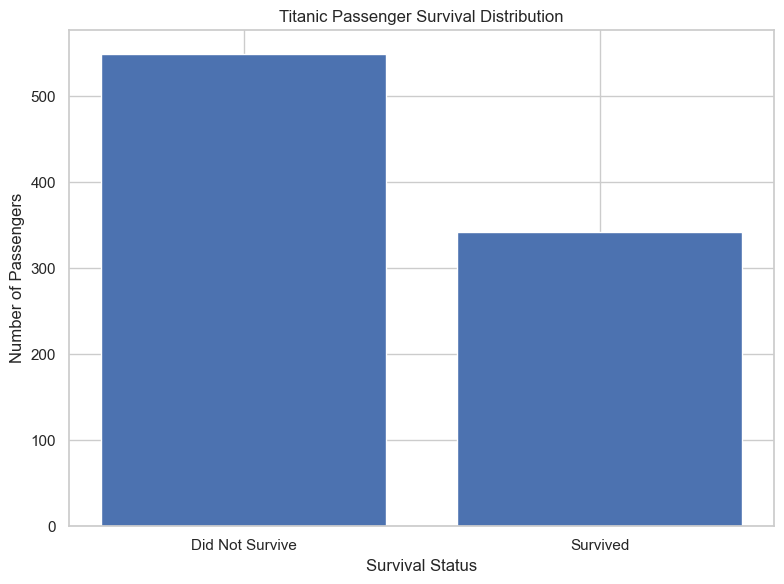

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_distribution.png


In [34]:
# ============================================================
# VISUALIZATION 1 - SURVIVAL DISTRIBUTION
# ============================================================

# Create a new figure
plt.figure(figsize=(8, 6))

# Count the number of passengers in each survival category
survival_counts = clean_train_df["Survived"].value_counts()

# Create a bar chart
plt.bar(
    ["Did Not Survive", "Survived"],
    [
        survival_counts.get(0, 0),
        survival_counts.get(1, 0)
    ]
)

# Add chart title
plt.title("Titanic Passenger Survival Distribution")

# Add axis labels
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

# Adjust layout
plt.tight_layout()

# Define output file path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_distribution.png"
)

# Save chart
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("Chart saved at:", output_file)

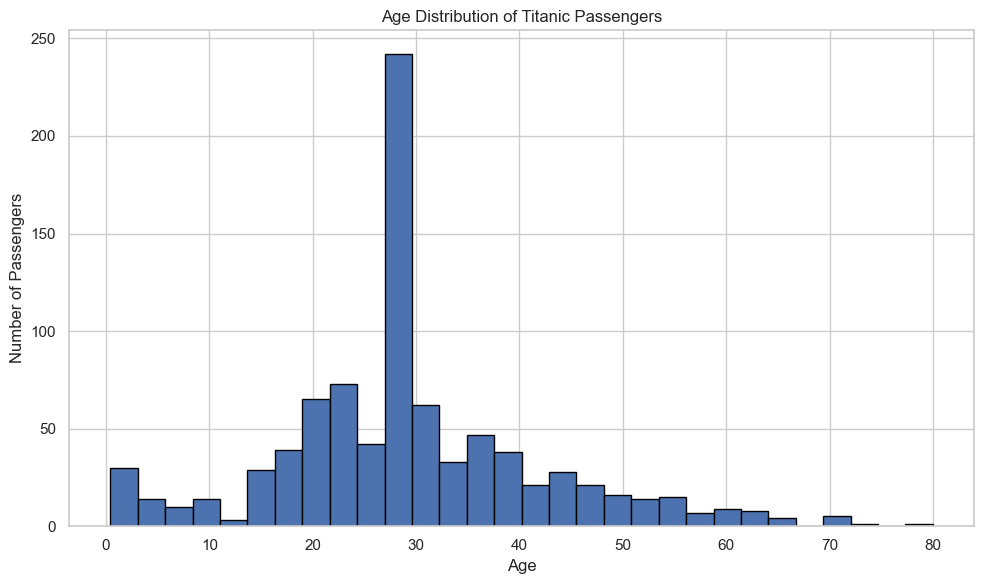

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\age_distribution.png


In [35]:
# ============================================================
# VISUALIZATION 2 - AGE DISTRIBUTION
# ============================================================

# Create figure
plt.figure(figsize=(10, 6))

# Create histogram of passenger ages
plt.hist(
    clean_train_df["Age"],
    bins=30,
    edgecolor="black"
)

# Add title
plt.title("Age Distribution of Titanic Passengers")

# Add axis labels
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "age_distribution.png"
)

# Save visualization
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display visualization
plt.show()

print("Chart saved at:", output_file)

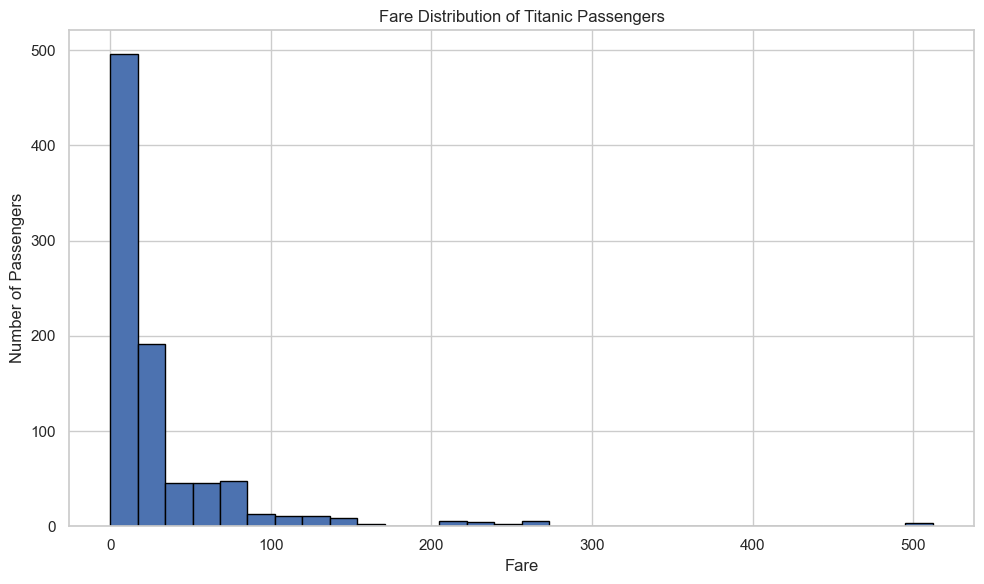

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\fare_distribution.png


In [36]:
# ============================================================
# VISUALIZATION 3 - FARE DISTRIBUTION
# ============================================================

# Create figure
plt.figure(figsize=(10, 6))

# Create histogram of passenger fares
plt.hist(
    clean_train_df["Fare"],
    bins=30,
    edgecolor="black"
)

# Add title
plt.title("Fare Distribution of Titanic Passengers")

# Add axis labels
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "fare_distribution.png"
)

# Save visualization
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display visualization
plt.show()

print("Chart saved at:", output_file)

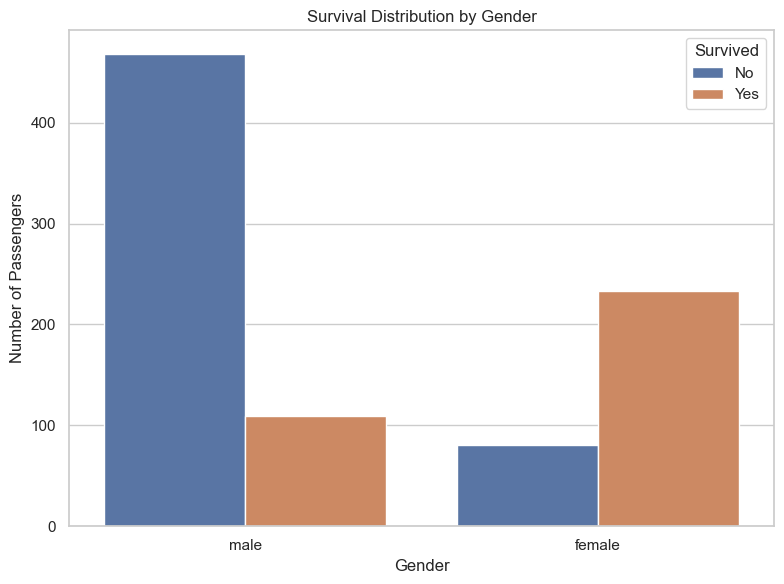

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_by_gender.png


In [37]:
# ============================================================
# VISUALIZATION 4 - SURVIVAL BY GENDER
# ============================================================

# Create figure
plt.figure(figsize=(8, 6))

# Create count plot using Seaborn
sns.countplot(
    data=clean_train_df,
    x="Sex",
    hue="Survived"
)

# Add title
plt.title("Survival Distribution by Gender")

# Add axis labels
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

# Add legend title
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_by_gender.png"
)

# Save chart
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("Chart saved at:", output_file)

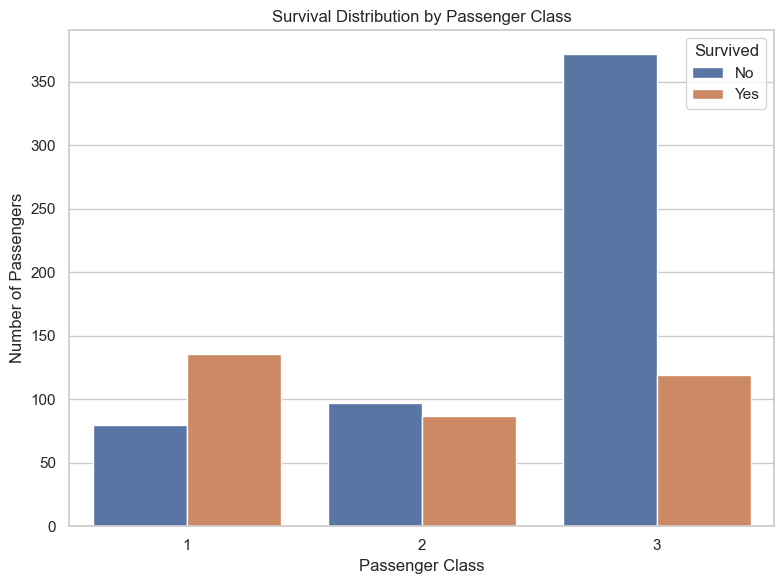

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_by_class.png


In [39]:
# ============================================================
# VISUALIZATION 5 - SURVIVAL BY PASSENGER CLASS
# ============================================================

# Create figure
plt.figure(figsize=(8, 6))

# Create count plot
sns.countplot(
    data=clean_train_df,
    x="Pclass",
    hue="Survived"
)

# Add title
plt.title("Survival Distribution by Passenger Class")

# Add axis labels
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

# Add legend
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_by_class.png"
)

# Save visualization
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display visualization
plt.show()

print("Chart saved at:", output_file)

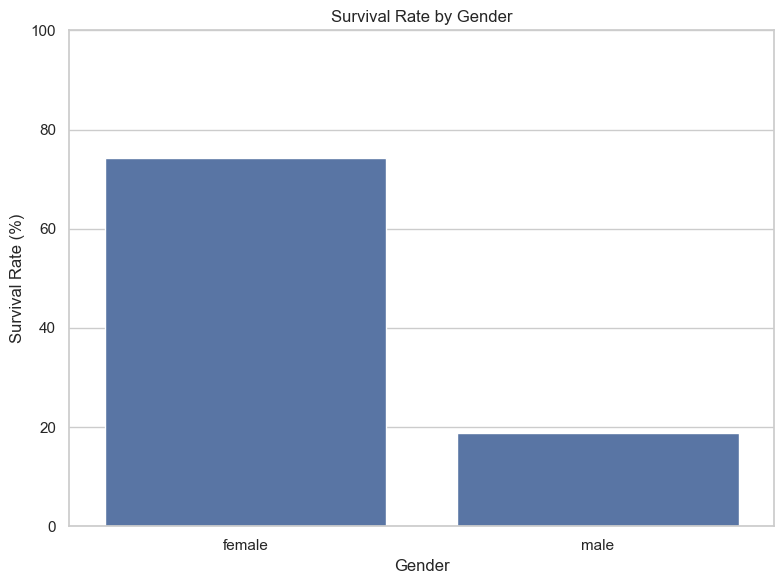

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_rate_by_gender.png


In [40]:
# ============================================================
# VISUALIZATION 6 - SURVIVAL RATE BY GENDER
# ============================================================

# Calculate survival rate by gender
gender_survival_rate = (
    clean_train_df
    .groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

# Rename columns for clarity
gender_survival_rate.columns = [
    "Sex",
    "Survival_Rate"
]

# Create figure
plt.figure(figsize=(8, 6))

# Create bar plot
sns.barplot(
    data=gender_survival_rate,
    x="Sex",
    y="Survival_Rate"
)

# Add title
plt.title("Survival Rate by Gender")

# Add axis labels
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

# Set y-axis range
plt.ylim(0, 100)

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_rate_by_gender.png"
)

# Save chart
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("Chart saved at:", output_file)

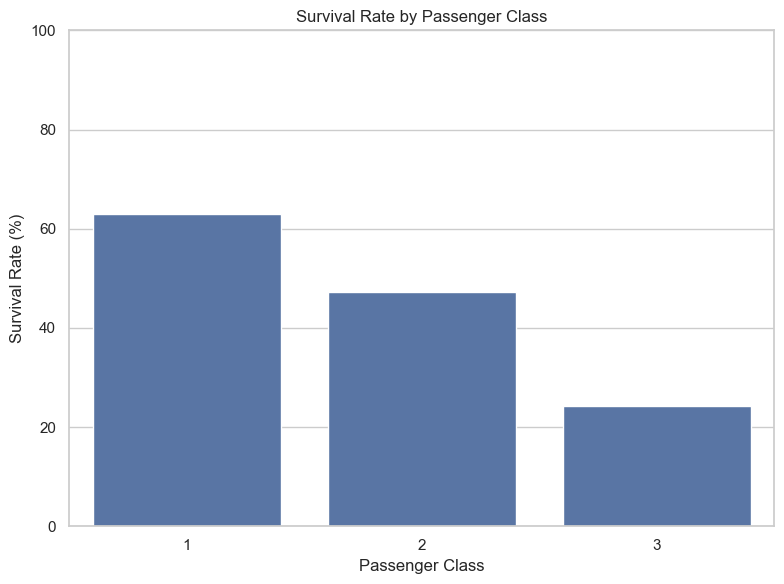

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_rate_by_class.png


In [41]:
# ============================================================
# VISUALIZATION 7 - SURVIVAL RATE BY PASSENGER CLASS
# ============================================================

# Calculate survival rate for each passenger class
class_survival_rate = (
    clean_train_df
    .groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

# Rename columns
class_survival_rate.columns = [
    "Pclass",
    "Survival_Rate"
]

# Create figure
plt.figure(figsize=(8, 6))

# Create bar plot
sns.barplot(
    data=class_survival_rate,
    x="Pclass",
    y="Survival_Rate"
)

# Add title
plt.title("Survival Rate by Passenger Class")

# Add labels
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

# Set y-axis range
plt.ylim(0, 100)

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_rate_by_class.png"
)

# Save visualization
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display visualization
plt.show()

print("Chart saved at:", output_file)

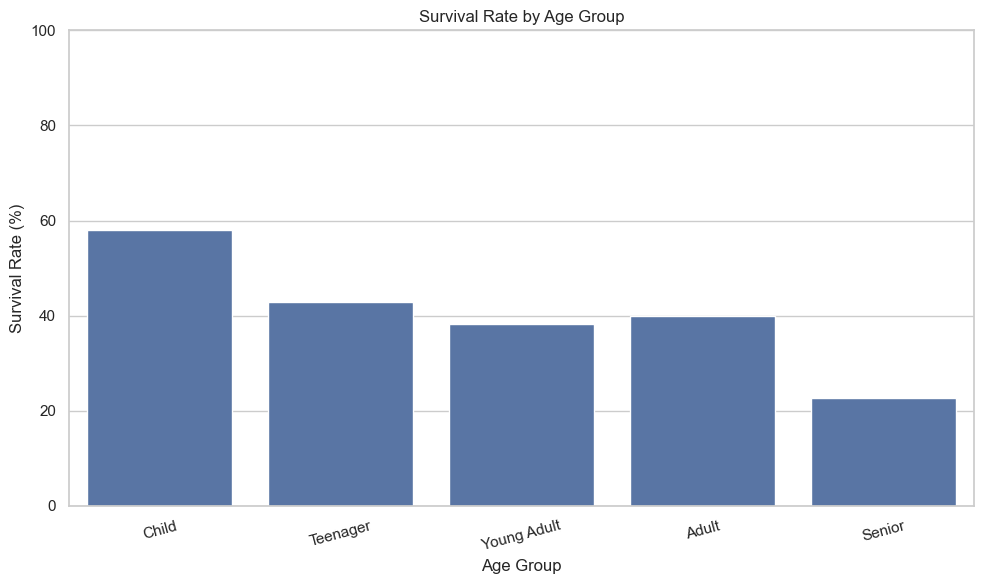

Chart saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\survival_rate_by_age_group.png


In [42]:
# ============================================================
# VISUALIZATION 8 - SURVIVAL RATE BY AGE GROUP
# ============================================================

# Calculate survival rate for each age group
age_group_rate = (
    clean_train_df
    .groupby("Age_Group", observed=False)["Survived"]
    .mean()
    .mul(100)
    .reset_index()
)

# Rename columns
age_group_rate.columns = [
    "Age_Group",
    "Survival_Rate"
]

# Create figure
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(
    data=age_group_rate,
    x="Age_Group",
    y="Survival_Rate"
)

# Add title
plt.title("Survival Rate by Age Group")

# Add labels
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

# Set y-axis range
plt.ylim(0, 100)

# Rotate x-axis labels for readability
plt.xticks(rotation=15)

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "survival_rate_by_age_group.png"
)

# Save chart
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("Chart saved at:", output_file)

In [43]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# Select only numerical columns
numeric_data = clean_train_df.select_dtypes(
    include=np.number
)

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Display correlation matrix
display(correlation_matrix)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


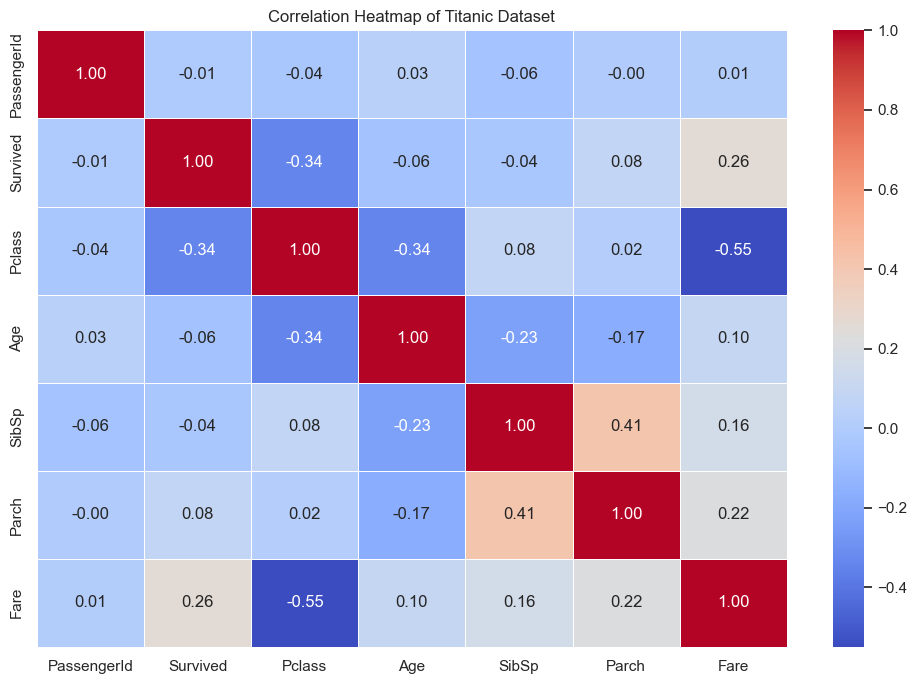

Heatmap saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\correlation_heatmap.png


In [44]:
# ============================================================
# VISUALIZATION 9 - CORRELATION HEATMAP
# ============================================================

# Create figure
plt.figure(figsize=(10, 7))

# Create correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Titanic Dataset")

# Adjust layout
plt.tight_layout()

# Define output path
output_file = os.path.join(
    FIGURES_PATH,
    "correlation_heatmap.png"
)

# Save heatmap
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display heatmap
plt.show()

print("Heatmap saved at:", output_file)

In [45]:
# ============================================================
# SAVE EXPLORATORY DATA ANALYSIS RESULTS
# ============================================================

# Save survival rate by gender
gender_survival_rate.to_csv(
    os.path.join(
        RESULTS_PATH,
        "survival_rate_by_gender.csv"
    ),
    index=False
)

# Save survival rate by passenger class
class_survival_rate.to_csv(
    os.path.join(
        RESULTS_PATH,
        "survival_rate_by_class.csv"
    ),
    index=False
)

# Save survival rate by age group
age_group_rate.to_csv(
    os.path.join(
        RESULTS_PATH,
        "survival_rate_by_age_group.csv"
    ),
    index=False
)

# Save correlation matrix
correlation_matrix.to_csv(
    os.path.join(
        RESULTS_PATH,
        "correlation_matrix.csv"
    )
)

print("EDA results saved successfully.")

EDA results saved successfully.


In [46]:
# ============================================================
# VERIFY GENERATED FIGURES
# ============================================================

# List all files generated in the figures directory
figure_files = os.listdir(FIGURES_PATH)

print("Generated Figure Files:")
print("--------------------------------")

for file in sorted(figure_files):
    print(file)

print("--------------------------------")
print("Total Figures:", len(figure_files))

Generated Figure Files:
--------------------------------
age_distribution.png
correlation_heatmap.png
fare_distribution.png
survival_by_class.png
survival_by_gender.png
survival_distribution.png
survival_rate_by_age_group.png
survival_rate_by_class.png
survival_rate_by_gender.png
--------------------------------
Total Figures: 9


In [47]:
# ============================================================
# MACHINE LEARNING - FEATURE SELECTION
# ============================================================

# Select features that are useful for predicting survival
# We intentionally exclude:
# - PassengerId: Identifier, not a meaningful predictive feature
# - Name: Text feature, not required for this basic model
# - Ticket: High-cardinality categorical feature
# - Cabin: Contains many missing values
# - Age_Group: Created for EDA, not required for the model

FEATURE_COLUMNS = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

# Create feature matrix
X = clean_train_df[FEATURE_COLUMNS].copy()

# Create target variable
y = clean_train_df["Survived"].copy()

print("Selected Features:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Selected Features:
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

Feature Matrix Shape: (891, 7)
Target Shape: (891,)


In [48]:
# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

# Convert categorical variables into numerical dummy variables
# drop_first=True avoids unnecessary duplicate information
X_encoded = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

# Display encoded dataset
display(X_encoded.head())

print("Encoded Feature Shape:", X_encoded.shape)

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


Encoded Feature Shape: (891, 8)


In [49]:
# ============================================================
# SPLIT DATA INTO TRAINING AND VALIDATION SETS
# ============================================================

# Split the training dataset into:
# 80% training data
# 20% validation data

X_train, X_validation, y_train, y_validation = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting shapes
print("Training Features Shape   :", X_train.shape)
print("Validation Features Shape:", X_validation.shape)

print("\nTraining Target Shape     :", y_train.shape)
print("Validation Target Shape   :", y_validation.shape)

Training Features Shape   : (712, 8)
Validation Features Shape: (179, 8)

Training Target Shape     : (712,)
Validation Target Shape   : (179,)


In [50]:
# ============================================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

# Create Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using training data
model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [51]:
# ============================================================
# GENERATE VALIDATION PREDICTIONS
# ============================================================

# Predict survival outcomes for validation data
y_validation_pred = model.predict(
    X_validation
)

# Display first 20 predictions
print("First 20 Validation Predictions:")
print(y_validation_pred[:20])

First 20 Validation Predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [52]:
# ============================================================
# MODEL ACCURACY
# ============================================================

# Calculate model accuracy
validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

# Display accuracy
print(
    f"Validation Accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

Validation Accuracy: 80.45%


In [53]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

# Generate detailed classification metrics
classification_report_text = classification_report(
    y_validation,
    y_validation_pred
)

# Display classification report
print(classification_report_text)

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [54]:
# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

# Define output path
classification_report_path = os.path.join(
    RESULTS_PATH,
    "classification_report.txt"
)

# Save report as a text file
with open(
    classification_report_path,
    "w"
) as file:
    file.write(classification_report_text)

print("Classification report saved at:")
print(classification_report_path)

Classification report saved at:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\results\classification_report.txt


In [55]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

# Calculate confusion matrix
cm = confusion_matrix(
    y_validation,
    y_validation_pred
)

# Display numerical confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


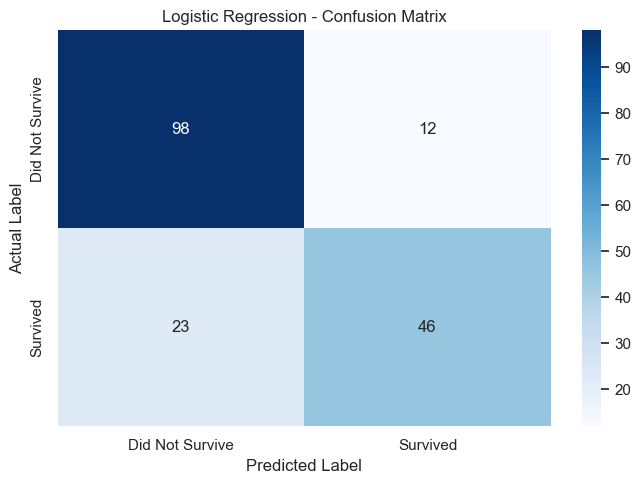

Confusion matrix saved at:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\figures\confusion_matrix.png


In [56]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

# Create figure
plt.figure(figsize=(7, 5))

# Create heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

# Add title
plt.title("Logistic Regression - Confusion Matrix")

# Add axis labels
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Adjust layout
plt.tight_layout()

# Define output path
confusion_matrix_path = os.path.join(
    FIGURES_PATH,
    "confusion_matrix.png"
)

# Save figure
plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

# Display figure
plt.show()

print("Confusion matrix saved at:")
print(confusion_matrix_path)

In [57]:
# ============================================================
# MODEL PERFORMANCE SUMMARY
# ============================================================

# Create a DataFrame containing the main model metric
model_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [validation_accuracy],
    "Accuracy_Percentage": [
        round(validation_accuracy * 100, 2)
    ]
})

# Display model performance
display(model_results)

,Model,Accuracy,Accuracy_Percentage
0,Logistic Regression,0.804469,80.45


In [58]:
# ============================================================
# SAVE MODEL PERFORMANCE RESULTS
# ============================================================

# Define output path
model_results_path = os.path.join(
    RESULTS_PATH,
    "model_results.csv"
)

# Save model performance
model_results.to_csv(
    model_results_path,
    index=False
)

print("Model results saved at:")
print(model_results_path)

Model results saved at:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\results\model_results.csv


In [59]:
# ============================================================
# LOGISTIC REGRESSION COEFFICIENT ANALYSIS
# ============================================================

# Create DataFrame containing model coefficients
feature_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

# Calculate absolute coefficient value
# This helps compare the magnitude of each coefficient
feature_coefficients["Absolute_Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)

# Sort by coefficient magnitude
feature_coefficients = feature_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

# Display coefficient analysis
display(feature_coefficients)

,Feature,Coefficient,Absolute_Coefficient
5,Sex_male,-2.559300,2.559300
0,Pclass,-1.092223,1.092223
7,Embarked_S,-0.381482,0.381482
6,Embarked_Q,0.278980,0.278980
2,SibSp,-0.244502,0.244502
3,Parch,-0.071126,0.071126
1,Age,-0.038566,0.038566
4,Fare,0.002239,0.002239


In [60]:
# ============================================================
# SAVE FEATURE COEFFICIENTS
# ============================================================

# Define output path
coefficient_path = os.path.join(
    RESULTS_PATH,
    "feature_coefficients.csv"
)

# Save coefficient analysis
feature_coefficients.to_csv(
    coefficient_path,
    index=False
)

print("Feature coefficients saved at:")
print(coefficient_path)

Feature coefficients saved at:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\results\feature_coefficients.csv


In [61]:
# ============================================================
# PREPARE COMPLETE TRAINING DATA FOR FINAL MODEL
# ============================================================

# Use the complete encoded training dataset
X_full = X_encoded.copy()

# Use the complete target variable
y_full = y.copy()

print("Full Training Feature Shape:", X_full.shape)
print("Full Training Target Shape :", y_full.shape)

Full Training Feature Shape: (891, 8)
Full Training Target Shape : (891,)


In [62]:
# ============================================================
# PREPARE ACTUAL TEST DATA FOR PREDICTION
# ============================================================

# Select the same features used during model training
X_actual_test = clean_test_df[
    FEATURE_COLUMNS
].copy()

# Convert categorical columns into numerical dummy variables
X_actual_test_encoded = pd.get_dummies(
    X_actual_test,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

# Make sure test data has exactly the same columns
# as the training feature matrix
X_actual_test_encoded = X_actual_test_encoded.reindex(
    columns=X_full.columns,
    fill_value=0
)

print(
    "Actual Test Feature Shape:",
    X_actual_test_encoded.shape
)

print(
    "Training Feature Shape:",
    X_full.shape
)

Actual Test Feature Shape: (418, 8)
Training Feature Shape: (891, 8)


In [63]:
# ============================================================
# TRAIN FINAL MODEL ON COMPLETE TRAINING DATA
# ============================================================

# Create a fresh Logistic Regression model
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train using all available labelled training data
final_model.fit(
    X_full,
    y_full
)

print(
    "Final Logistic Regression model trained "
    "using the complete training dataset."
)

Final Logistic Regression model trained using the complete training dataset.


In [64]:
# ============================================================
# PREDICT SURVIVAL FOR ACTUAL TEST DATA
# ============================================================

# Generate predictions for the 418 test passengers
test_predictions = final_model.predict(
    X_actual_test_encoded
)

# Display first 20 predictions
print("First 20 Test Predictions:")
print(test_predictions[:20])

# Display total number of predictions
print(
    "\nTotal Predictions:",
    len(test_predictions)
)

First 20 Test Predictions:
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1]

Total Predictions: 418


In [65]:
# ============================================================
# CREATE FINAL PREDICTIONS FILE
# ============================================================

# Create a DataFrame containing PassengerId and prediction
predictions_df = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

# Display first five predictions
display(predictions_df.head())

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [66]:
# ============================================================
# SAVE FINAL PREDICTIONS
# ============================================================

# Define output path
predictions_path = os.path.join(
    PROCESSED_DATA_PATH,
    "predictions.csv"
)

# Save predictions
predictions_df.to_csv(
    predictions_path,
    index=False
)

print("Final predictions saved successfully.")
print("Saved at:", predictions_path)

Final predictions saved successfully.
Saved at: C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\processed_data\predictions.csv


In [67]:
# ============================================================
# VERIFY FINAL PREDICTIONS
# ============================================================

# Display prediction file information
print("Prediction File Shape:", predictions_df.shape)

print("\nPrediction Counts:")
print(
    predictions_df["Survived"].value_counts()
)

print("\nFirst 10 Predictions:")
display(
    predictions_df.head(10)
)

Prediction File Shape: (418, 2)

Prediction Counts:
Survived
0    263
1    155
Name: count, dtype: int64

First 10 Predictions:


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [68]:
# ============================================================
# FINAL PROJECT OUTPUT VERIFICATION
# ============================================================

print("================================================")
print("FINAL PROJECT OUTPUT VERIFICATION")
print("================================================")

# List visualization files
print("\nFIGURES:")
for file in sorted(os.listdir(FIGURES_PATH)):
    print(" -", file)

# List result files
print("\nRESULTS:")
for file in sorted(os.listdir(RESULTS_PATH)):
    print(" -", file)

# List processed datasets
print("\nPROCESSED DATA:")
for file in sorted(os.listdir(PROCESSED_DATA_PATH)):
    print(" -", file)

print("\n================================================")
print("Task 4 output generation completed successfully.")
print("================================================")

FINAL PROJECT OUTPUT VERIFICATION

FIGURES:
 - age_distribution.png
 - confusion_matrix.png
 - correlation_heatmap.png
 - fare_distribution.png
 - survival_by_class.png
 - survival_by_gender.png
 - survival_distribution.png
 - survival_rate_by_age_group.png
 - survival_rate_by_class.png
 - survival_rate_by_gender.png

RESULTS:
 - classification_report.txt
 - correlation_matrix.csv
 - feature_coefficients.csv
 - missing_values.csv
 - model_results.csv
 - statistical_summary.csv
 - survival_rate_by_age_group.csv
 - survival_rate_by_class.csv
 - survival_rate_by_gender.csv

PROCESSED DATA:
 - predictions.csv
 - test_cleaned.csv
 - titanic_cleaned.csv

Task 4 output generation completed successfully.


In [69]:
# ============================================================
# KEY FINDINGS - DATASET INSIGHTS
# ============================================================

# Calculate overall survival rate
overall_survival_rate = (
    clean_train_df["Survived"].mean() * 100
)

# Identify gender with the highest survival rate
highest_gender = survival_by_gender.idxmax()
highest_gender_rate = survival_by_gender.max()

# Identify passenger class with the highest survival rate
highest_class = survival_by_class.idxmax()
highest_class_rate = survival_by_class.max()

# Display important findings
print("================================================")
print("KEY DATASET FINDINGS")
print("================================================")

print(
    f"1. Overall passenger survival rate: "
    f"{overall_survival_rate:.2f}%"
)

print(
    f"2. Gender with highest survival rate: "
    f"{highest_gender} ({highest_gender_rate:.2f}%)"
)

print(
    f"3. Passenger class with highest survival rate: "
    f"Class {highest_class} ({highest_class_rate:.2f}%)"
)

print(
    f"4. Average passenger age: "
    f"{clean_train_df['Age'].mean():.2f} years"
)

print(
    f"5. Average passenger fare: "
    f"{clean_train_df['Fare'].mean():.2f}"
)

print(
    f"6. Logistic Regression validation accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

KEY DATASET FINDINGS
1. Overall passenger survival rate: 38.38%
2. Gender with highest survival rate: female (74.20%)
3. Passenger class with highest survival rate: Class 1 (62.96%)
4. Average passenger age: 29.36 years
5. Average passenger fare: 32.20
6. Logistic Regression validation accuracy: 80.45%


In [70]:
# ============================================================
# SAVE KEY FINDINGS
# ============================================================

# Create a dictionary containing the major findings
key_findings = {
    "Overall Survival Rate (%)": round(
        overall_survival_rate, 2
    ),

    "Highest Survival Gender": highest_gender,

    "Highest Gender Survival Rate (%)": round(
        highest_gender_rate, 2
    ),

    "Highest Survival Passenger Class": highest_class,

    "Highest Class Survival Rate (%)": round(
        highest_class_rate, 2
    ),

    "Average Passenger Age": round(
        clean_train_df["Age"].mean(), 2
    ),

    "Average Passenger Fare": round(
        clean_train_df["Fare"].mean(), 2
    ),

    "Logistic Regression Accuracy (%)": round(
        validation_accuracy * 100, 2
    )
}

# Convert findings into a DataFrame
key_findings_df = pd.DataFrame(
    list(key_findings.items()),
    columns=["Finding", "Value"]
)

# Display findings
display(key_findings_df)

# Save findings
key_findings_path = os.path.join(
    RESULTS_PATH,
    "key_findings.csv"
)

key_findings_df.to_csv(
    key_findings_path,
    index=False
)

print("Key findings saved at:")
print(key_findings_path)

,Finding,Value
0,Overall Survival Rate (%),38.38
1,Highest Survival Gender,female
2,Highest Gender Survival Rate (%),74.2
3,Highest Survival Passenger Class,1
4,Highest Class Survival Rate (%),62.96
5,Average Passenger Age,29.36
6,Average Passenger Fare,32.2
7,Logistic Regression Accuracy (%),80.45


Key findings saved at:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-04-Data-Science-Tool-Mastery\output\results\key_findings.csv


# Data Science Tool Mastery Summary

## NumPy

NumPy was used for numerical and statistical computations,
including mean, median, standard deviation, minimum, and
maximum calculations.

## Pandas

Pandas was extensively used for:

- Loading CSV datasets
- Data inspection
- Missing-value analysis
- Duplicate detection
- GroupBy operations
- Feature creation
- Data cleaning
- Data transformation
- Exporting processed datasets

## Matplotlib

Matplotlib was used to create basic data visualizations,
including age distribution, fare distribution, and survival
distribution charts.

## Seaborn

Seaborn was used for advanced statistical visualizations,
including survival analysis by gender and passenger class,
age-group analysis, and correlation heatmaps.

## Scikit-learn

Scikit-learn was used for:

- Train-validation splitting
- Categorical feature preparation
- Logistic Regression
- Model prediction
- Accuracy calculation
- Classification report
- Confusion matrix

## Jupyter Notebook

Jupyter Notebook was used as the primary environment to
document and execute the complete data science workflow.

# Project Workflow Summary

The project followed a complete end-to-end data science workflow:

1. Dataset loading
2. Dataset inspection
3. Data quality assessment
4. Missing-value analysis
5. Duplicate analysis
6. Numerical analysis using NumPy
7. Data manipulation using Pandas
8. Data cleaning
9. Feature engineering
10. Exploratory data analysis
11. Data visualization using Matplotlib
12. Statistical visualization using Seaborn
13. Feature selection
14. Categorical feature encoding
15. Train-validation split
16. Logistic Regression model training
17. Model evaluation
18. Final model training
19. Prediction on unseen test data
20. Exporting results and predictions

# Key Findings and Insights

The analysis of the Titanic dataset revealed several important
patterns.

- Passenger survival was strongly associated with gender.
- Passenger class was an important factor in survival outcomes.
- The survival rate differed considerably between passenger classes.
- The dataset contained missing values, particularly in the Age
  and Cabin-related information, which required appropriate
  preprocessing.
- Numerical analysis showed substantial variation in passenger
  fares.
- Visualization helped identify relationships between demographic
  characteristics and survival outcomes.
- Logistic Regression successfully learned survival patterns from
  the selected passenger features.
- The trained final model was also applied to the separate
  418-record test dataset to generate predictions.

These findings demonstrate how data science tools can be combined
to transform raw data into meaningful analytical insights and
machine learning predictions.

# Conclusion

This Data Science Tool Mastery project successfully demonstrates
practical proficiency with several industry-standard Python data
science tools and libraries.

The project started with raw Titanic training and test datasets
and followed a complete data science workflow. Pandas was used for
data loading, inspection, cleaning, transformation, grouping,
statistical analysis, and exporting processed data. NumPy was used
for numerical and statistical calculations.

Matplotlib and Seaborn were used to create informative visualizations
that helped identify patterns in passenger age, fare, gender,
passenger class, and survival. These visualizations made the
exploratory analysis easier to understand.

Scikit-learn was then used to prepare machine learning features,
split the labelled dataset into training and validation sets,
train a Logistic Regression model, and evaluate the model using
accuracy, classification metrics, and a confusion matrix.

After evaluation, a final model was trained using the complete
labelled training dataset. The model was then applied to the
separate test dataset containing 418 passengers, and the resulting
predictions were exported as a CSV file.

Overall, this project demonstrates practical knowledge of the
complete data science lifecycle, from data ingestion and
preprocessing to visualization, machine learning, evaluation,
and prediction. The project also provides reusable outputs and
analysis files that can be included as a portfolio project.

# ============================================================
# COMPLETE PROJECT OUTPUT VERIFICATION
# ============================================================

print("=" * 60)
print("TASK 04 - FINAL OUTPUT VERIFICATION")
print("=" * 60)

# ------------------------------------------------------------
# FIGURES
# ------------------------------------------------------------

print("\n[1] FIGURES")
print("-" * 60)

figure_files = sorted(
    os.listdir(FIGURES_PATH)
)

for file in figure_files:
    print("✓", file)

print(
    f"\nTotal Figures Generated: {len(figure_files)}"
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n[2] ANALYSIS RESULTS")
print("-" * 60)

result_files = sorted(
    os.listdir(RESULTS_PATH)
)

for file in result_files:
    print("✓", file)

print(
    f"\nTotal Result Files: {len(result_files)}"
)

# ------------------------------------------------------------
# PROCESSED DATA
# ------------------------------------------------------------

print("\n[3] PROCESSED DATA")
print("-" * 60)

processed_files = sorted(
    os.listdir(PROCESSED_DATA_PATH)
)

for file in processed_files:
    print("✓", file)

print(
    f"\nTotal Processed Files: {len(processed_files)}"
)

# ------------------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 04 NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 60)